# Hop length optimization

Tutorial 2 of 2 on tuning `DSTFT`'s parameters (tutorial 1: [`window_optimization.ipynb`](window_optimization.ipynb) covers `win_length`). This one is about `hop_length`: the spacing between frame centers.

`hop_length` controls how far apart consecutive analysis frames are placed. It trades off temporal detail against redundancy/cost: a **small** hop places frames densely, so nothing between them is missed, but most of what neighboring frames see overlaps — more compute for little extra information where the signal is stationary. A **large** hop is cheaper but can straddle or miss a brief event entirely if it falls between two frame centers.

`DSTFT` lets `hop_length` be a **learnable tensor** instead of a constant, via `hop_mode`:

- `"fixed"` — a constant, not learnable (the `torch.stft` baseline).
- `"constant"` — one learnable scalar, shared by every hop.
- `"time"` — one learnable value per frame; frame *positions* come from a running cumulative sum of these hops, so frames can bunch up around a fast event and spread out over a stationary stretch.

(There's no `"frequency"` or `"time-frequency"` analog here — frame position is shared across all frequency bins of a frame, so hop length only ever varies over time.)

This notebook: (1) shows the trade-off concretely with a fixed hop, (2) trains `hop_length` with gradient descent, (3) reads the learned hop-length map to see *where* frames moved, (4) checks reconstruction still works.

In [1]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(device, torch.__version__)
torch.manual_seed(1802)

%load_ext autoreload
%autoreload 2
%matplotlib inline

cpu 2.13.0+cu130


## 1. Signal and loss

In [2]:
def entropy_loss(x: torch.Tensor):
    """A simple loss function to encourage spectrogram sparsity."""
    x1 = torch.reshape(x, (x.shape[0], -1))  # B, N
    probs = torch.div(x1.T, x1.sum(dim=-1)).T  # B, N
    entropy = -(
        probs * torch.clamp(torch.log(probs), min=torch.finfo(x.dtype).min)
    ).sum(dim=-1)  # B
    return entropy.mean()

In [3]:
from math import pi


# Same signal as window_optimization.ipynb: a slow tone throughout, a fast tone
# that only appears halfway through — a single event whose onset a hop grid can
# either resolve or miss depending on where it falls.
duration = 1024
sr = 5
t = torch.arange(0, duration, 1 / sr, dtype=dtype, device=device) / float(duration)

slow_tone = torch.cos(2 * pi * 40.0 * t * sr)
fast_tone = torch.cos(2 * pi * 180.0 * t * sr)
mask = (t > 0.5).float()

x = (slow_tone + mask * fast_tone)[None, :].to(device)

## 2. The trade-off, with a *fixed* hop

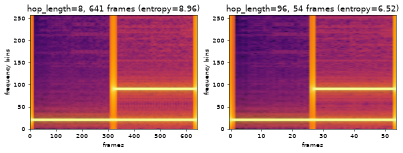

In [4]:
import matplotlib.pyplot as plt

from dstft import DSTFT


plt.rcParams["figure.dpi"] = 45  # keep saved notebook outputs small

n_fft = 512
win_length = 256

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, h in zip(axes, [8, 96], strict=True):
    dstft = DSTFT(win_length=win_length, n_fft=n_fft, hop_length=h, window_mode="fixed")
    dstft.initialize(x)
    spec, _ = dstft(x)
    loss = entropy_loss(spec).item()
    dstft.plot_spec(
        spec,
        ax=ax,
        show=False,
        colorbar=False,
        title=f"hop_length={h}, {spec.shape[-1]} frames (entropy={loss:.2f})",
    )
fig.tight_layout()
plt.show()

`hop_length=8` produces many frames (fine temporal grid, more compute) that pin down the fast tone's onset precisely. `hop_length=96` produces far fewer frames — cheaper, but the onset now lands wherever it happens to fall between two widely-spaced frame centers, which blurs *when* it starts. A single fixed hop has to commit to one point on this trade-off for the entire signal.

(The two entropy values above aren't directly comparable to each other — `entropy_loss` normalizes *within* each spectrogram, and the two configurations have a different number of frames. It's only meaningful to compare entropy *across configurations that share the same frame count* — which is the case everywhere else in this notebook, since `hop_length` starts at the same fixed value before any of it is optimized.)

## 3. Letting `hop_length` adapt: `hop_mode`

In [5]:
hop_length = 32
epochs = 3_000
lr = 1
patience = 9
factor = 0.1
lr_stop = 1e-3

hop_modes = ["fixed", "constant", "time"]
results = {}
trained = {}

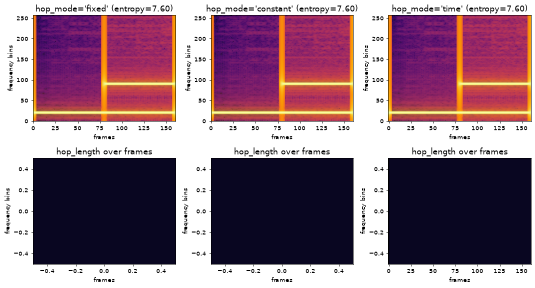

In [6]:
from dstft.visualization import plot_win_lengths


fig, axes = plt.subplots(2, len(hop_modes), figsize=(4 * len(hop_modes), 6.5))

for col, hop_mode in enumerate(hop_modes):
    # window_mode="fixed" here so only the hop is varying in this section
    dstft = DSTFT(
        win_length=win_length,
        n_fft=n_fft,
        hop_length=hop_length,
        window_mode="fixed",
        hop_mode=hop_mode,
    )
    dstft.initialize(x)

    if hop_mode == "fixed":
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()
    else:
        optimizer = torch.optim.Adam(dstft.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode="min", factor=factor, patience=patience
        )
        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)
            spec, _ = dstft(x)
            loss = entropy_loss(spec)
            loss.backward()
            optimizer.step()
            scheduler.step(loss.detach())
            if optimizer.param_groups[0]["lr"] < lr_stop:
                break
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()

    results[hop_mode] = final_loss
    trained[hop_mode] = dstft
    dstft.plot_spec(
        spec,
        ax=axes[0, col],
        show=False,
        colorbar=False,
        title=f"hop_mode={hop_mode!r} (entropy={final_loss:.2f})",
    )
    plot_win_lengths(
        dstft.hop_length,
        ax=axes[1, col],
        show=False,
        colorbar=False,
        vmin=dstft.hop_length_min,
        vmax=dstft.hop_length_max,
        title="hop_length over frames",
    )

fig.tight_layout()
plt.show()

Top row: the resulting spectrogram and its entropy. Bottom row: the learned `hop_length` itself, read out per frame via `plot_win_lengths` (generic over whichever tensor you hand it — window length or hop length).

Notice `constant` and `time` barely move away from `fixed` here, unlike the window-length case. That's not a training issue — it's a real property of this setup, worth understanding rather than papering over: with `window_mode="fixed"` (kept fixed here on purpose, so only the hop is varying), the analysis window's *shape* is evaluated using only the very first frame's fractional offset — and frame 0 always sits at position `0 * hop_length = 0`, for *any* `hop_length`. So the window shape never actually responds to `hop_length` at all, and a magnitude-based loss like `entropy_loss` (which only ever sees window-shaped frames) gets exactly zero gradient for it — not a small one, exactly zero, confirmed directly on `dstft._raw_hop_length.grad`. `hop_length` still moves the frame *positions* (that part works, and shows up in `inverse.ipynb`), but nothing here is pulling it anywhere.

The gradient stops being zero as soon as the window is allowed to vary per frame (`window_mode="time"` or richer) instead of being a single fixed shape — that's exactly [`window_optimization.ipynb`](window_optimization.ipynb)'s setup, and combining the two (`hop_mode` *and* `window_mode` both adaptive at once) is a natural next experiment, left for later.

In [7]:
for hop_mode, loss in results.items():
    print(f"{hop_mode:>10s}: entropy = {loss:.4f}")

     fixed: entropy = 7.5969
  constant: entropy = 7.5969
      time: entropy = 7.5973


## 4. Reconstruction still works

As with `window_mode`, a learned `hop_length` doesn't break invertibility: `DSTFT.inverse` still reconstructs the original signal from the transform. See [`inverse.ipynb`](inverse.ipynb) for reconstruction accuracy across every mode; here's a quick check with the trained `hop_mode="time"` model from above.

reconstruction error: 5.542053571616634e-08


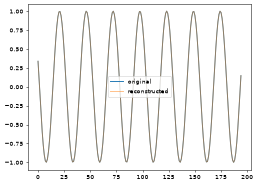

In [8]:
dstft = trained["time"]
spec, stft = dstft(x)
x_hat = dstft.inverse(stft)

# Plot an interior slice: WOLA normalization divides by a near-zero denominator
# at the signal edges, where fewer frames overlap, which inflates error there.
plt.plot(x[0, 5:200].detach().cpu(), label="original")
plt.plot(x_hat[0, 5:200].detach().cpu(), alpha=0.5, label="reconstructed")
plt.legend()
print("reconstruction error:", (x - x_hat).abs().mean().item())

## Next

[`window_optimization.ipynb`](window_optimization.ipynb) covers the other learnable parameter, `win_length`. Optimizing the window's *shape* (not just its length) or the `magnitude_power` exponent are natural follow-ups, left for a future notebook.